# Data Papers from the Journal of Open Humanities Data (JOHD)

The main goal of this activity is to understand if a specific Digital Humanities venue, i.e. the [Journal of Open Humanities Data](https://openhumanitiesdata.metajnl.com/), includes references or mentions to external material appropriately dedicated to either describing the management of the data a paper describes, such as a Data Management Plan (DMP), or detailing precisely the workflow used to produce these data, e.g. published as a particular workflow document or as a computational notebook. In particular, we focus on specific kinds of articles published in JOHD, i.e. Data Papers, which are concise descriptions of a humanities research object with high reuse potential. These articles are particularly suitable for our activities since they describe only data, and thus they should have a higher possibility of having such documents referenced, being the data the focus of the article. It is worth clarifying, though, that such Data Papers usually include a methodological section that provides hints about the process of creation of such data. However, the information in that section is often insufficient to have a complete reproduction of the workflow steps one has to run to recreate the same set of data.

This document introduces the workflow description (and, simultaneously, part of its execution) adopted for:
* gathering the necessary data from JOHD, i.e. the Data Papers to consider;
* processing the gathered Data Papers to catch references and mentions to external documents dedicated to either the management or the creation workflow of the data.

The workflow described in this document is semi-automatic. Some of the steps are fully automated by means of developed Python scripts. Other steps must be performed manually to complement and correct the results obtained via automatic procedures. It will be carefully described in the text, along with the various passages.

## 1. Preliminaries

Before introducing the various steps of the workflow, it is important to create all the folders and variables necessary for the processing. First of all, there are the import statements used for enabling the reuse of specific Python modules.

In [34]:
from requests import get
from bs4 import BeautifulSoup
from os import makedirs
from os.path import exists, sep
from json import dump, load
from pandas import DataFrame

The package `requests` is used for downloading material from the Web, while the package `bs4` is used to open in Python HTML and XML documents, to simplify their processing. A few functions of the `os` package are also used to create the various folders where to store the data, while some functions and classes of `json` and `pandas` are used to store, process, and visualise the data obtained.

The following code creates the basic folders used for storing the JOHD articles, in both PDF and XML formats. In addition, it also defines the path for a file, i.e. `data.json`, which will be used to store all the information used for the analysis.

In [35]:
data_path = "data" + sep
pdf_path = data_path + "pdf" + sep
xml_path = data_path + "xml" + sep
data_file = data_path + "data.json"

if not exists(pdf_path):
    makedirs(pdf_path)

if not exists(xml_path):
    makedirs(xml_path)

Finally, we set a few variables to define the URL template of the various articles to download. 

We also define a list of strings with the volume numbers to consider (from which to download the articles). We set it to `"11"` in this run to consider only articles published in 2025, but we can easily extend it to include additional volumes by adding other string numbers in the list. 

In addition, we also define a list of terms to look for in each downloaded article. The idea is that if an article contains at least one of these terms, there is a reasonable probability that it refers to or mentions an external document of interest for the data introduced in the article. In this run, seven terms are actually considered: *data management plan* and its acronym (*dmp*), *research data management* and its acronym (*rdm*), the broad concept of *data management* and, finally, two terms - i.e. *protocol* and *workflow* - that are commonly used to define processes devised for the creation and analysis of data.

In [36]:
base_url = "https://openhumanitiesdata.metajnl.com"
volume_url = base_url + "/%s/volume/%s/issue/1"

volumes = ["11"]

search_items = [
    "data management plan",
    "dmp",
    "research data management",
    "rdm",
    "data management",
    "protocol",
    "workflow"
]

## 2. Data gathering [computational step]

In this step, we download the webpage of the volumes of interest. Then, we process the webpage to find out all the URLs of the Data Papers the volume contains. Finally, for each Data Paper URL, we download the related webpage to extract some basic metadata and to download the XML and PDF files of the article under consideration.

The entire **step is performed automatically** by running the following Python code. It creates a file `data.json` which contains, in JSON, the following information about each article downloaded:
* `doi`: the DOI of the article;
* `webpage_url`: the URL of the article in JOHD;
* `xml_url`: the URL of the XML version of the article in JOHD;
* `pdf_url`: the URL of the PDF version of the article in JOHD;
* `xml_path`: the local path of the XML version of the article that has been downloaded;
* `pdf_path`: the local path of the PDF version of the article that has been downloaded;
* `title`: the title of the article;
* `description`: a string (initially empty) with a justification that explains whether the article contains or not a reference/mention to a DMP/workflow;
* `dmp_or_workflow`: a boolean value (initially set to `False`) that says whether the article contains or not a reference/mention to a DMP/workflow.

In [37]:
if not exists(data_file):
    for volume in volumes:
        res = get(volume_url % (volume, volume))
        if res.status_code == 200:
            data = []
            html = BeautifulSoup(res.text)
            data_papers = html.find("h2", string="Data Paper").find_parent().find_all("article")
            for data_paper in data_papers:
                data_paper_url = base_url + data_paper.find("a")["href"]
                data_paper_doi = data_paper_url.replace(base_url + "/en/articles/", "")
                data_paper_res = get(data_paper_url)
                if data_paper_res.status_code == 200:
                    data_paper_html = BeautifulSoup(data_paper_res.text)
                    data_paper_pdf_url = base_url + data_paper_html.find("a", string="PDF (English)")["href"]
                    data_paper_xml_url = base_url + data_paper_html.find("a", string="XML (English)")["href"]
                    data_paper_title = data_paper_html.find("title").string.replace(" | Journal of Open Humanities Data", "")
                    
                    file_name = data_paper_doi.split("/")[1]
                    data_paper_xml_file_path = xml_path + file_name + ".xml"
                    if not exists(data_paper_xml_file_path):
                        data_paper_xml_file = get(data_paper_xml_url)
                        if data_paper_xml_file.status_code == 200:
                            with open(data_paper_xml_file_path, "wb") as f:
                                f.write(data_paper_xml_file.content)
                        else:
                            print("Problems while downloading the data paper XML format with URL %s - status code: %s", (data_paper_xml_url, res.status_code))
    
                    data_paper_pdf_file_path = pdf_path + file_name + ".pdf"
                    if not exists(data_paper_pdf_file_path):
                        data_paper_pdf_file = get(data_paper_pdf_url)
                        if data_paper_pdf_file.status_code == 200:
                            with open(data_paper_pdf_file_path, "wb") as f:
                                f.write(data_paper_pdf_file.content)
                        else:
                            print("Problems while downloading the data paper PDF format with URL %s - status code: %s", (data_paper_xml_url, res.status_code))        
    
                    data.append({
                        "doi": data_paper_doi,
                        "webpage_url": data_paper_url,
                        "xml_url": data_paper_xml_url,
                        "pdf_url": data_paper_pdf_url,
                        "xml_path": data_paper_xml_file_path.replace(data_path, ""),
                        "pdf_path": data_paper_pdf_file_path.replace(data_path, ""),
                        "title": data_paper_title,
                        "description": "",
                        "dmp_or_workflow": False
                    })
    
                    print("Gathered data for data paper with DOI", data_paper_doi)
                else:
                    print("Problems while downloading the data paper webpage with URL %s - status code: %s", (data_paper_url, res.status_code))        
        
            with open(data_file, "w", encoding="utf-8") as f:
                dump(data, f, ensure_ascii=False, indent=4)
                print("Metadata stored.")
        else:
            print("Problems while downloading the webpage - status code:", res.status_code)
else:
    with open(data_file, "r", encoding="utf-8") as f:
        data = load(f)
        print("Data already exists, nothing new to download.")

Data already exists, nothing new to download.


## 3. Identification of potential articles of interest [computational step]

All the XML versions of the articles downloaded are parsed to find out if their text contains any of the terms introduced in the preliminaries (Section 1). The rationale is that, instead of looking manually at all the downloaded articles, we focus our attention only on those that contain words that potentially indicate the presence of a mention to external documents defining DMPs, workflows, etc.

The entire **step is performed automatically** by running the following Python code. The information stored in the previous step in the file `data.json` is extended in this step by adding two additional fields:
* `match_found`: a boolean that is set to `True` if any of the specified terms have been matched;
* `matched_terms`: all the terms that were matched in the article.

In [40]:
for record in data:
    record_file_path = data_path + record["xml_path"]
    with open(record_file_path, "r", encoding="utf-8") as f:
        text = BeautifulSoup(f, features="xml").find("body").get_text().lower()
        items_found = []
        for search_item in search_items:
            if search_item in text:
                items_found.append(search_item)

        record.update({
            "match_found": len(items_found) > 0,
            "matched_terms": "; ".join(items_found)
        })

with open(data_file, "w", encoding="utf-8") as f:
    dump(data, f, ensure_ascii=False, indent=4)
    print("Metadata updated with textual matches.")

Metadata updated with textual matches.


The following code returns a list of all downloaded articles for which a match has been found, and also produce an horizontal bar chart with the number of times (x-axis) the specified terms have been mentioned (y-axis). Only terms that have been matched at least once are included in the diagram.

10.5334/johd.271 pdf/johd.271.pdf workflow
10.5334/johd.248 pdf/johd.248.pdf workflow
10.5334/johd.268 pdf/johd.268.pdf data management; workflow
10.5334/johd.297 pdf/johd.297.pdf protocol
10.5334/johd.314 pdf/johd.314.pdf workflow
10.5334/johd.326 pdf/johd.326.pdf data management; workflow
10.5334/johd.339 pdf/johd.339.pdf workflow
10.5334/johd.328 pdf/johd.328.pdf workflow
10.5334/johd.342 pdf/johd.342.pdf protocol
10.5334/johd.373 pdf/johd.373.pdf protocol
10.5334/johd.379 pdf/johd.379.pdf workflow
10.5334/johd.374 pdf/johd.374.pdf workflow
10.5334/johd.397 pdf/johd.397.pdf protocol
10.5334/johd.393 pdf/johd.393.pdf protocol
10.5334/johd.371 pdf/johd.371.pdf protocol; workflow
10.5334/johd.429 pdf/johd.429.pdf data management
10.5334/johd.432 pdf/johd.432.pdf workflow

Number of records matching any of the terms: 17 (out of 48).


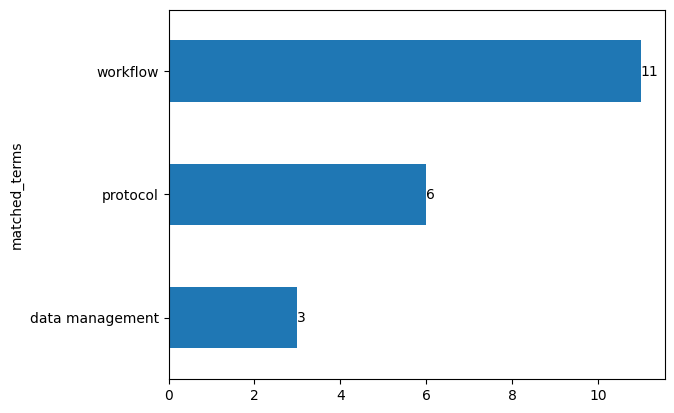

In [41]:
matches_terms = []

for record in data:
    if record["match_found"]:
        matches_terms.append(record)
        print(record["doi"], record["pdf_path"], record["matched_terms"])
print("\nNumber of records matching any of the terms: %s (out of %s)." % (len(matches_terms), len(data)))

df = DataFrame.from_records(data)
df = df.query("matched_terms != ''")
df["matched_terms"] = df["matched_terms"].apply(lambda x: x.split('; '))
df = df.explode("matched_terms")
count = df["matched_terms"].value_counts(ascending=True)
ax = count.plot(kind="barh")
for container in ax.containers:
    ax.bar_label(container)

## 4. Updating article information [manual step]

Given the list of articles returned in the previous step, we open the PDF version of each article to see if it contains references or mentions to external documents describing the management or the creation of the data it introduces. In particular, we check if at least one of the following conditions is valid:

1. We read the article and see if it contains a reference or a mention to such an external document;
2. We see if such a document is included in the data deposited and introduced in the article.

The entire **step must be performed manually** by opening each of the identified articles. In case one of the two options above is valid, the field `dmp_or_workflow` of the `data.json` file for the article under consideration should be set to `True`. In any case, the field `description` should be populated with an explanation which clarifies whether the article with one of the matched terms includes or not a reference or mention to a DMP or workflow document.

## 5. Summarising the articles with references to external documents [computational step]

This last step provides a quick summary of all the articles that include a reference or mention to a DMP or workflow document. In particular, the following code reports, for each of these articles, its DOI, the local PDF path, the terms that have been matched in Step 3, and the related description.

The entire **step is performed automatically** by running the following Python code.

In [42]:
with open(data_file, "r", encoding="utf-8") as f:
    data = load(f)

matches = []

for record in data:
    if record["dmp_or_workflow"]:
        matches.append(record)
        print("\nDOI:", record["doi"], "\nPDF path:", record["pdf_path"], 
              "\nMatched terms:", record["matched_terms"], "\nDescription:", record["description"])

print("\nNumber of record specifying DMP and/or workflow: %s (out of %s)." % (len(matches), len(data))) 


DOI: 10.5334/johd.297 
PDF path: pdf/johd.297.pdf 
Matched terms: protocol 
Description: The authors provided a description of the protocol followed as an external document (https://doi.org/10.5281/zenodo.10777131).

DOI: 10.5334/johd.328 
PDF path: pdf/johd.328.pdf 
Matched terms: workflow 
Description: The authors refer to another article (i.e. https://doi.org/10.1163/24523666-bja10047) which contains an extensive natural language documentation of the workflow they adopted to create the data.

DOI: 10.5334/johd.379 
PDF path: pdf/johd.379.pdf 
Matched terms: workflow 
Description: While mentioned and described in the article, there is no reference to external documentation detailing the workflow. A computational workflow is included in the data deposited.

DOI: 10.5334/johd.371 
PDF path: pdf/johd.371.pdf 
Matched terms: protocol; workflow 
Description: While mentioned and described in the article, there is no reference to external documentation detailing the workflow. A computation